In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import curve_fit
import pandas as pd


In [14]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu) ** 2 / (2 * sigma**2))

In [2]:
phase_df = pd.read_csv("./fft_phase_analysis/5Hz/phase_analysis_results.csv")

In [7]:
phase_df.head()

,Main Camera,Other Camera,Max Peak,Phase Offset,Window Size,Step Size,Slope,Intercept,Slope Error,Intercept Error,File Pair
0,12574,12606,490.411937,3,60,10,1.110223e-16,3.000000,1.871232e-23,2.511525e-15,2026_03_24__17_20_25_cube.fits vs 2026_03_24__...
1,12574,12606,484.226597,3,60,10,1.110223e-16,3.000000,1.871232e-23,2.511525e-15,2026_03_24__17_20_25_cube.fits vs 2026_03_24__...
2,12574,12606,475.974806,-12,60,10,3.044397e-03,-1.472727,4.303846e-03,1.074670e+00,2026_03_24__17_20_25_cube.fits vs 2026_03_24__...
3,12574,12606,484.834457,-5,60,10,1.110223e-16,-5.000000,1.277487e-23,2.311986e-15,2026_03_24__17_20_25_cube.fits vs 2026_03_24__...
4,12574,12606,485.063903,-6,60,10,4.503171e-03,-0.627273,4.941005e-03,1.233768e+00,2026_03_24__17_20_25_cube.fits vs 2026_03_24__...


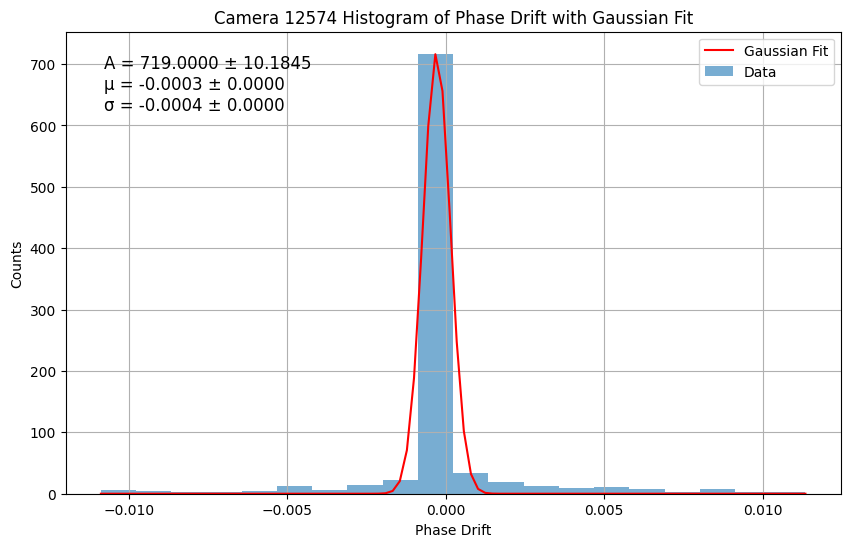

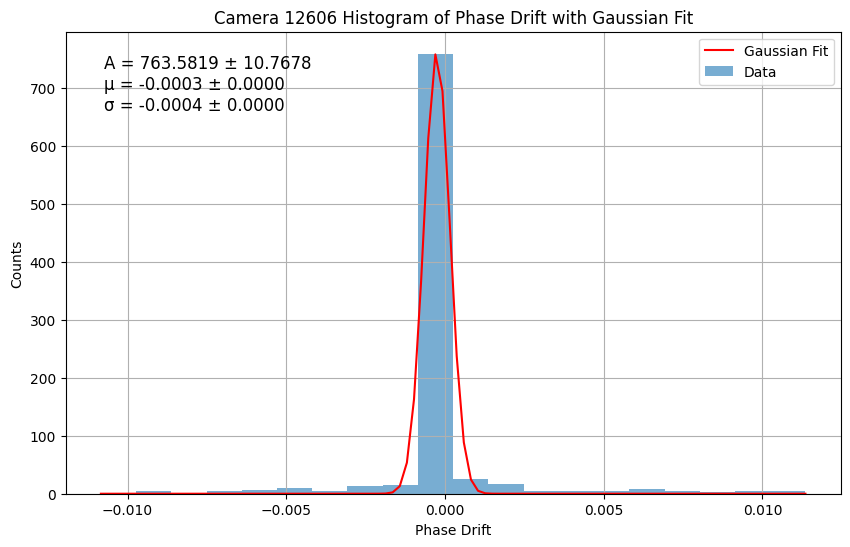

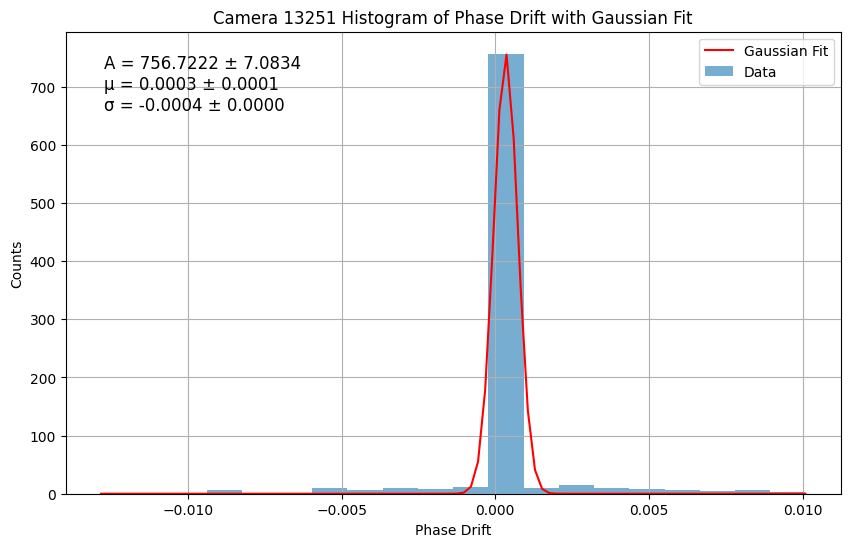

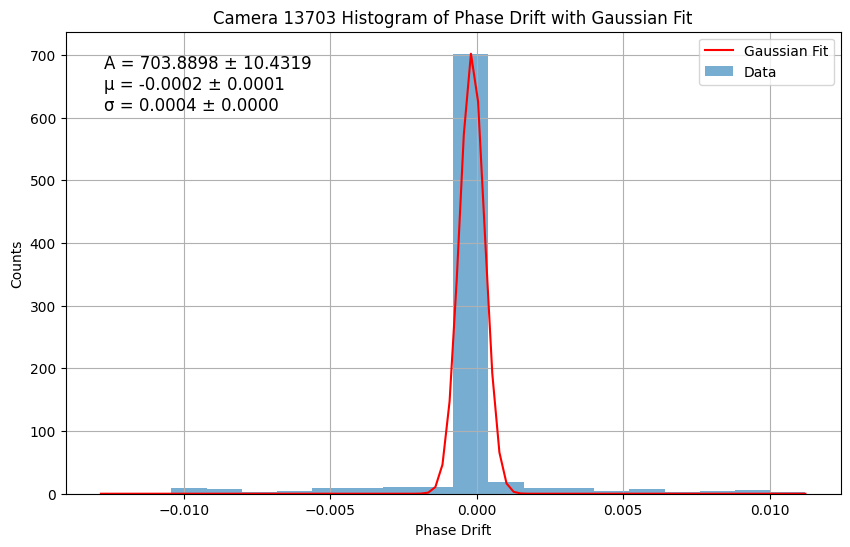

In [22]:
camera_ids = [12574, 12606, 13251, 13703]

for id in camera_ids:

    df_data = phase_df[(phase_df["Main Camera"] == id) | (phase_df["Other Camera"] == id)]
    slope = df_data["Slope"].values
    cnts, bin_edges = np.histogram(slope, bins=20, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2


    popt, pcov = curve_fit(gaussian, bin_centers, cnts, p0=[1, np.mean(slope), np.std(slope)])
    err = np.sqrt(np.diag(pcov))

    x_fit = np.linspace(bin_edges[0], bin_edges[-1], 100)
    y_fit = gaussian(x_fit, *popt)


    plt.figure(figsize=(10, 6))
    plt.bar(bin_centers, cnts, width=bin_edges[1] - bin_edges[0], alpha=0.6, label="Data")
    plt.plot(x_fit, y_fit, color="red", label="Gaussian Fit")
    plt.xlabel("Phase Drift")
    plt.ylabel("Counts")
    plt.title(f"Camera {id} Histogram of Phase Drift with Gaussian Fit")
    plt.legend()
    plt.grid()

    text_str = f"A = {popt[0]:.4f} ± {err[0]:.4f}\nμ = {popt[1]:.4f} ± {err[1]:.4f}\nσ = {popt[2]:.4f} ± {err[2]:.4f}"
    plt.text(0.05, 0.95, text_str, transform=plt.gca().transAxes, fontsize=12, verticalalignment="top")
    plt.savefig(f"./fft_phase_analysis/5Hz/Camera_{id}__Phase_Drift_Fit.png")

